<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/06_2_Ciencia_de_Datos_Semana_06_Retos_S_P500_JOHAN_ORDO%C3%91EZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ESTUDIANTE:** JOHAN DAVID ORDOÑEZ CASTRO - **CODIGO:** 224393001

# **Taller Práctico: Análisis de Series de Tiempo Financieras como Procesos Estocásticos**

Maestría en Ingeniería Electrónica

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera


En este cuaderno construiremos un marco empírico para analizar datos del mercado de valores, específicamente el índice S&P 500, tratándolo como un proceso estocástico en tiempo discreto $X[n]$.
De acuerdo con la teoría de procesos estocásticos, cada resultado de un experimento se mapea a una colección de variables aleatorias en el tiempo. Aquí, consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.
Para que todas las trayectorias partan del mismo estado inicial, normalizaremos cada año dividiendo todos sus valores por el valor de cierre del primer día del año, asegurando que $X[0]=1$.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf # libreria de finanazas de Yahoo
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# **1. Adquisición y Preparación del Dataset (Data Wrangling)**
Extraeremos el histórico del índice S&P 500 (^GSPC) desde el primero de enero de 1970. Dado que un año financiero típico tiene aproximadamente 252 días de cotización, extraeremos los primeros 250 días de cada año para formar una matriz homogénea de dimensión $M \times N$, donde $M$ es el número de años (realizaciones) y $N=250$ el número de instantes de tiempo.

[*********************100%***********************]  1 of 1 completed


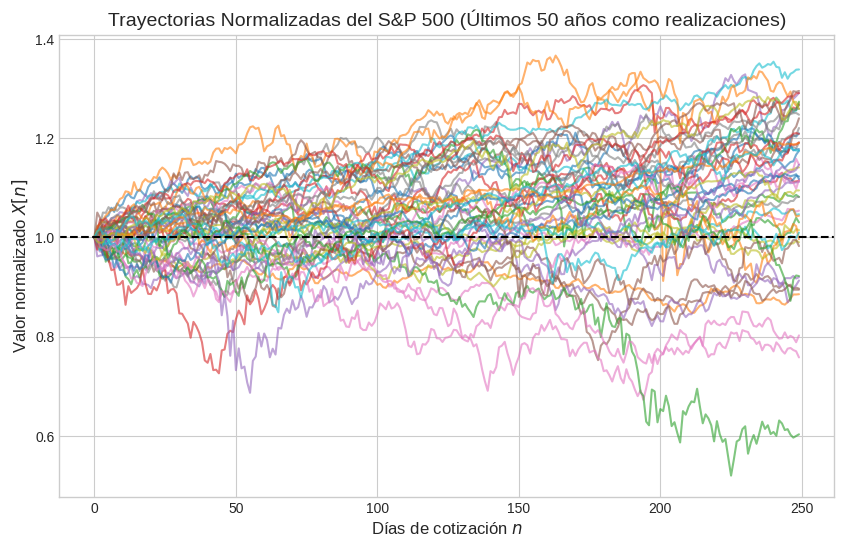

In [ ]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
# Si yfinance devuelve un MultiIndex, lo aplanamos
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n
X = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los precios del año correspondiente
    datos = precios[precios.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recordan los datos a N_dias
        X[i, :] = datos[:N_dias]

    elif len(datos) < N_dias: # Si tiene menos de 250 días, rellenamos con el último valor
        # np.pad agrega 0 datos al inicio y N_dias - len(datos) datos al final
        # La opción 'edge' rellena con el último valor encontrado en la serie
        X[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'edge')

    else:
        X[i, :] = datos

    # Normalización: X[n] = Precio[n] / Precio[0]
    X[i, :] = X[i, :]/X[i, 0]

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.6, lw=1.5)

plt.title('Trayectorias Normalizadas del S&P 500 (Últimos 50 años como realizaciones)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Valor normalizado $X[n]$', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--')
plt.show()

# **Reto 1: Caracterización de Primer Orden (Estimación de PDFs)**
Para un tiempo discreto fijo $n$, $X[n]$ representa una variable aleatoria caracterizada por su función de densidad de probabilidad $f_X​(x,n)$.
Tu tarea:
1. Seleccione los datos del ensamble (la matriz X) para los instantes de tiempo (días) n=1, n=100 y n=200.
2. Estime y grafique la PDF para cada uno de estos días en una misma figura con 3 subgráficos (puedes usar sns.histplot con la opción kde=True).
3. Análisis: Observe las tres gráficas. ¿Qué sucede con la dispersión (varianza) de los posibles valores del índice a medida que avanza el año? Argumenta tu respuesta en una celda de texto.

In [ ]:
# Incluya aquí el código del Reto 1
# seleccion de datos
X_1 = X[:,1]
X_100 = X[:,100]
X_200 = X[:,200]

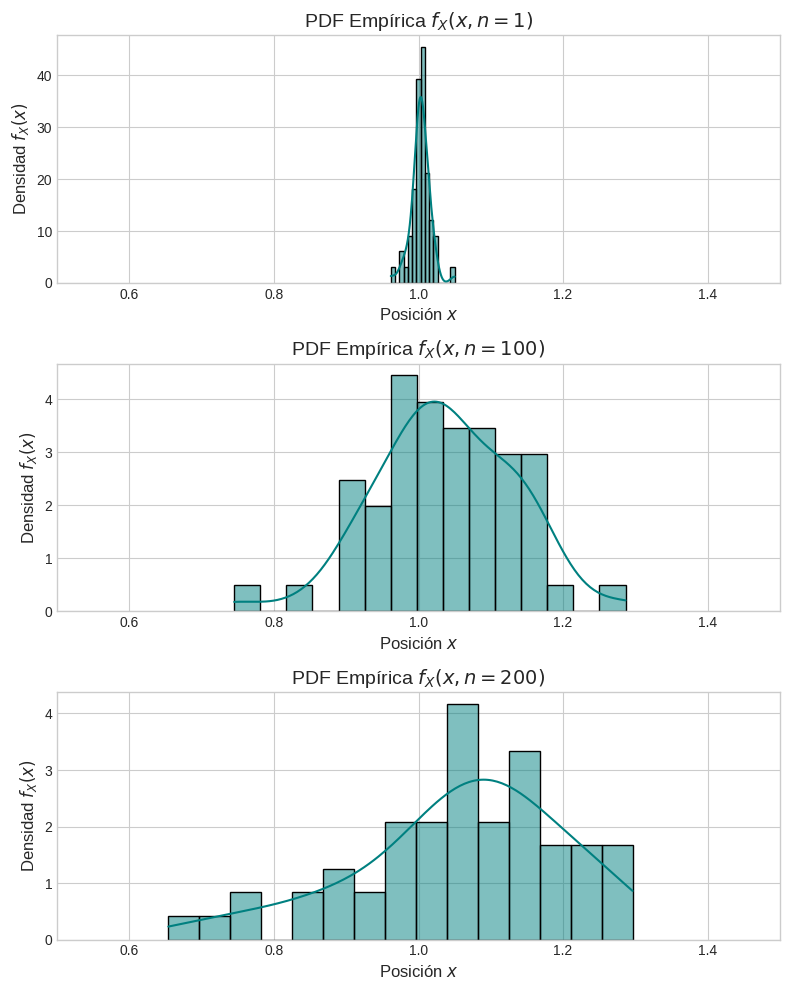

In [ ]:
# Definimos los pasos de tiempo a evaluar
pasos_a_evaluar = [1, 100, 200]

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i, n_step in enumerate(pasos_a_evaluar):
    # Extraemos transversalmente la posición de las M realizaciones en el paso n_step
    X_en_t = X[:, n_step]

    # Estimamos la PDF empírica usando un histograma y estimación de densidad de kernel (KDE)
    sns.histplot(X_en_t, kde=True, stat="density", ax=axes[i], color='teal', bins=15)

    axes[i].set_title(f'PDF Empírica $f_X(x, n={n_step})$', fontsize=14)
    axes[i].set_xlabel('Posición $x$', fontsize=12)
    axes[i].set_ylabel('Densidad $f_X(x)$', fontsize=12)
    axes[i].set_xlim([0.5, 1.5])

    # Fijamos el límite del eje X basado en el paso final N para observar cómo crece la dispersión
    #axes[i].set_xlim([-np.sqrt(N)*3, np.sqrt(N)*3])

plt.tight_layout()
plt.show()



## ANALISIS GRAFICO:

Observando las tres gráficas de izquierda a derecha (n = 1, n = 100, n = 200), se puede identificar claramente una tendencia creciente en la dispersión del índice a medida que avanza el año:
Comportamiento por período:

- n = 1 (inicio del año): La distribución es muy concentrada, con valores del índice entre aproximadamente 0.97 y 1.04. La curva es alta y estrecha, indicando baja varianza. El índice se mantiene muy cercano a 1.0.
- n = 100 (mitad del año): La dispersión aumenta notablemente. Los valores del índice se extienden entre ~0.75 y 1.30. La distribución se aplana y ensancha, reflejando mayor incertidumbre sobre el valor real del índice.
- n = 200 (fin del año): La dispersión es máxima. Los valores del índice abarcan desde ~0.65 hasta ~1.35 o más. La distribución es aún más plana e irregular, con mayor varianza acumulada.

## CONCLUSIÓN:

Cada nueva perturbación aleatoria diaria se acumula sobre las anteriores, por lo que el rango de posibles valores del índice se amplía progresivamente. Al inicio del año (n pequeño), hay pocas perturbaciones acumuladas y el índice se mantiene cerca de su valor inicial (1.0). Al avanzar el año (n grande), las desviaciones acumuladas pueden ser considerablemente mayores, resultando en una distribución mucho más dispersa.

# **Reto 2: Valor Esperado y Varianza del Proceso Estocástico**
El primer momento probabilístico o valor esperado del proceso se define como $\mu[n]=E\{X[n]\}$. Su varianza se define como $\mathrm{var}\{X[n]\}=\mathbf{E}\{(X[n]−\mu[n])^2\}$. La tarea:

1. Calcule empíricamente el valor esperado $\mu[n]$ promediando a través del ensamble (las $M$ realizaciones) para cada uno de los $N$ días.
2. Calcule empíricamente la varianza transversal para cada uno de los $N$ días.
3. Grafique el valor esperado empírico $\mu[n]$ en función de $n$ (días de cotización). Añade una línea de referencia en el nivel base $X[0]=1$.
4. Grafique la varianza empírica en función de $n$ en otro panel.
5. Análisis: Un proceso es Estacionario en Sentido Amplio (WSS) si su valor esperado es constante en el tiempo y su función de autocorrelación depende únicamente de la diferencia de tiempo $\tau$. Basado en las gráficas, ¿el índice S&P 500 puede modelarse como un proceso estocástico WSS? ¿Por qué?

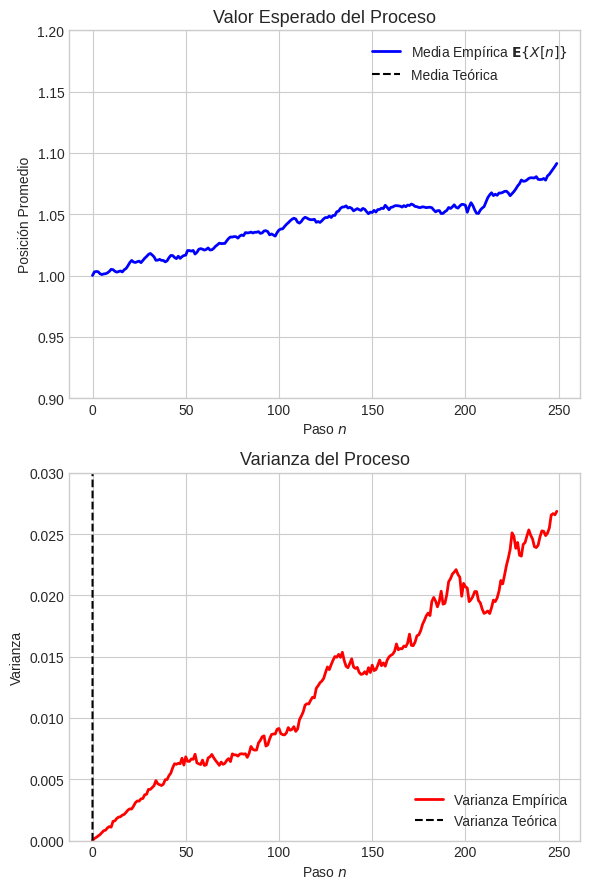

In [ ]:


# 1. Valor esperado empírico (media transversal sobre las M realizaciones)
mu_empirica = np.mean(X, axis=0)

# 2. Varianza empírica (varianza transversal sobre las M realizaciones)
var_empirica = np.var(X, axis=0)

n_array = np.arange(249 + 1)

# Visualización comparativa
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

# Gráfica del Valor Esperado
ax1.plot(n_array, mu_empirica, label=r'Media Empírica $\mathbf{E}\{ X[n] \}$', color='blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', label='Media Teórica')
ax1.set_title('Valor Esperado del Proceso', fontsize=13)
ax1.set_xlabel('Paso $n$')
ax1.set_ylabel('Posición Promedio')
ax1.set_ylim(0.9, 1.2)
ax1.legend()

# Gráfica de la Varianza
ax2.plot(n_array, var_empirica, label='Varianza Empírica', color='red', lw=2)
ax2.plot(n_array, n_array, color='black', linestyle='--', label='Varianza Teórica')
ax2.set_title('Varianza del Proceso', fontsize=13)
ax2.set_xlabel('Paso $n$')
ax2.set_ylabel('Varianza')
ax2.set_ylim(0, 0.03)
ax2.legend()

plt.tight_layout()
plt.show()

##ANALISIS GRAFICO:
No, el S&P 500 no puede modelarse como WSS, y las gráficas lo explican.

- Condición 1 — Media constante

Para que sea WSS la media tiene que ser la misma en todo momento, pero en las gráficas se ve que la media empírica no se queda quieta, va derivando a medida que avanza el tiempo. Entonces esta condición no se cumple.

- Condición 2 — Autocorrelación que solo dependa de τ

Esta condición tampoco se cumple, puesto que la autocorrelación esta dependiendo de la ubicación absoluta en el tiempo, violando la segunda condición WSS.

## CONCLUSION:
la distribución PDF se va aplanando y ensanchando, o sea la dispersión aumenta con el tiempo. Si el proceso fuera WSS, esas tres gráficas deberían verse prácticamente igual, y claramente no es así.
Por eso el S&P 500 se comporta más como una caminata aleatoria, donde la incertidumbre se va acumulando con el tiempo, lo cual es lo opuesto a ser estacionario.

# **Reto 3: Función de Autocorrelación y Autocovarianza para $n_1​=100$**

1. Fije el día de referencia $n_1​=100$. Calcule un arreglo con la autocorrelación empírica $R_{XX}​(100,n_2​)$ barriendo todos los días $n_2\in{0,…,249}$.
2. Calcule un arreglo con la autocovarianza empírica $C_{XX}​(100,n_2​)$ para los mismos valores de $n_2$​.
3. Grafique ambas funciones en un mismo plano. Señale con una línea vertical el instante $n_1​=100$.
4. Análisis: ¿Cuál es la relación teórica entre la función de autocovarianza $C_{XX}​(n_1​,n_2​)$ evaluada en $n_1​=n_2​=100$ y la varianza del proceso en ese mismo instante calculada en el Reto 2? Verifique empíricamente si los valores coinciden.

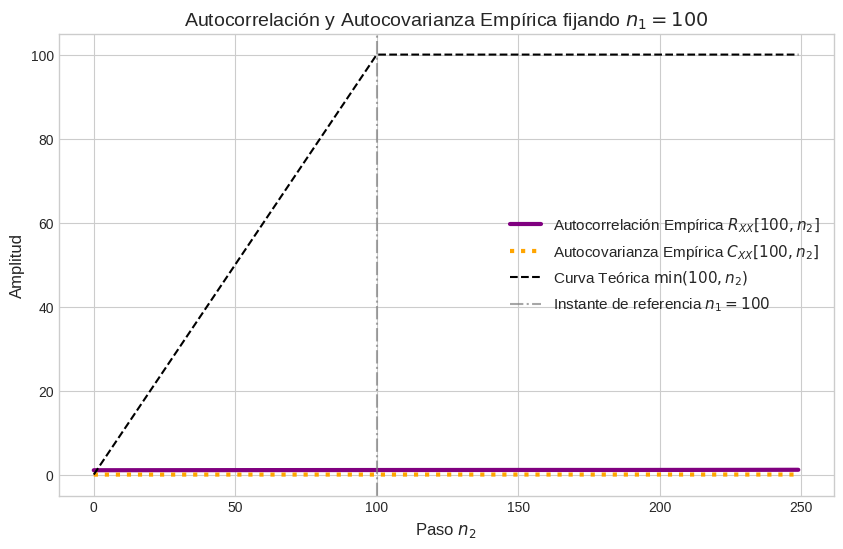

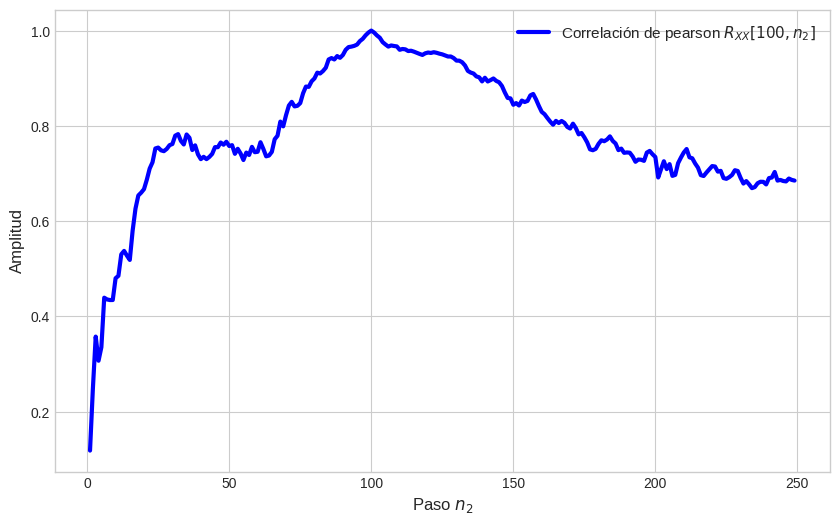

In [ ]:
# Incluya aquí el código del Reto 3
n1 = 100
N= 249
R_XX_empirica = np.zeros(N + 1)
C_XX_empirica = np.zeros(N + 1)
correlacion_pearson = np.zeros(N + 1)

# Cálculo a través del ensamble de las M realizaciones
for n2 in range(N + 1):
    # Autocorrelación: Esperanza del producto E[X(t1)*X(t2)]
    R_XX_empirica[n2] = np.mean(X[:, n1] * X[:, n2])

    # Autocovarianza: R_XX(t1,t2) - mu(t1)*mu(t2)
    C_XX_empirica[n2] = R_XX_empirica[n2] - (mu_empirica[n1] * mu_empirica[n2])

    # coeficiente de pearson para correlación
    correlacion_pearson[n2]= C_XX_empirica[n2]/ np.sqrt(var_empirica[n1]*var_empirica[n2])



# Autocorrelación / Autocovarianza Teórica para Caminata Aleatoria es min(t1, t2)
R_XX_teorica = [min(n1, n2) for n2 in range(N + 1)]

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(range(N + 1), R_XX_empirica, label=f'Autocorrelación Empírica $R_{{XX}}[{n1}, n_2]$', color='purple', lw=3)
plt.plot(range(N + 1), C_XX_empirica, label=f'Autocovarianza Empírica $C_{{XX}}[{n1}, n_2]$', color='orange', linestyle=':', lw=3)
plt.plot(range(N + 1), R_XX_teorica, label=f'Curva Teórica $\\min({n1}, n_2)$', color='black', linestyle='--')

plt.axvline(n1, color='gray', linestyle='-.', alpha=0.7, label=f'Instante de referencia $n_1 = {n1}$')

plt.title(f'Autocorrelación y Autocovarianza Empírica fijando $n_1 = {n1}$', fontsize=14)
plt.xlabel('Paso $n_2$', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(fontsize=11)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(N + 1), correlacion_pearson, label=f'Correlación de pearson $R_{{XX}}[{n1}, n_2]$', color='blue', lw=3)
plt.xlabel('Paso $n_2$', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(fontsize=11)
plt.show()


# **Reto 4: Matriz de Autocovarianza**
1. Calcule la matriz de autocovarianza empírica completa a partir de la matriz de realizaciones $X$. (Pista: np.cov es útil, pero asegúrese de definir correctamente si las variables están en las filas o en las columnas usando el argumento rowvar). El resultado debe ser una matriz de dimensión $250\times 250$.
2. Grafique esta matriz como un mapa de calor 2D (heatmap). Puede usar plt.imshow, sns.heatmap o plt.pcolormesh.
3. Asegúrate de incluir una barra de colores (colorbar) e identificar correctamente los ejes $n_1​$ y $n_2$​.
4. Análisis: Observe la diagonal principal del mapa de calor (donde $n_1​=n_2$​). ¿Qué estadística del proceso representa esta diagonal y cómo concuerda su evolución de color con la gráfica de varianza que obtuvo en el Reto 2?

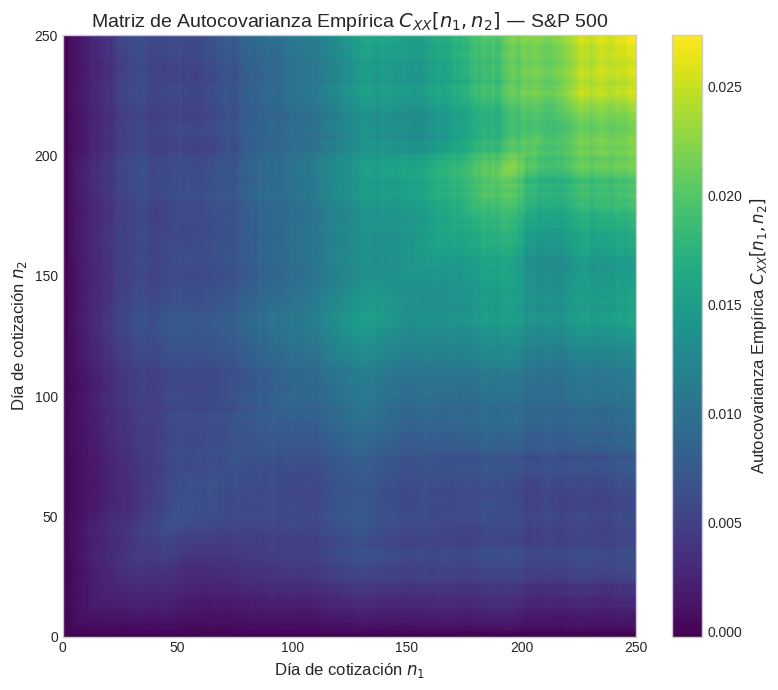

C_XX(100, 100)  = 0.009313
var_empirica[100] = 0.009147
Diferencia absoluta: 1.66e-04


In [ ]:
# Calculamos la matriz de autocovarianza empírica de dimensión (N_dias x N_dias)
# np.cov asume que las filas son variables, por eso usamos rowvar=False
# para que las columnas (días) sean las variables
C_XX_matriz = np.cov(X, rowvar=False)  # Resultado: (250, 250)

# Visualización como mapa de calor 2D
fig, ax = plt.subplots(figsize=(8, 7))

img = ax.imshow(C_XX_matriz, origin='lower', cmap='viridis',
                extent=[0, N_dias, 0, N_dias], aspect='auto')

cbar = plt.colorbar(img, ax=ax)
cbar.set_label('Autocovarianza Empírica $C_{XX}[n_1, n_2]$', fontsize=12)

ax.set_title('Matriz de Autocovarianza Empírica $C_{XX}[n_1, n_2]$ — S&P 500', fontsize=14)
ax.set_xlabel('Día de cotización $n_1$', fontsize=12)
ax.set_ylabel('Día de cotización $n_2$', fontsize=12)
ax.grid(False)

plt.tight_layout()
plt.show()

# Verificación numérica: C_XX(100, 100) vs var_empirica[100]
C_100_100 = C_XX_matriz[100, 100]
var_100 = var_empirica[100]
print(f"C_XX(100, 100)  = {C_100_100:.6f}")
print(f"var_empirica[100] = {var_100:.6f}")
print(f"Diferencia absoluta: {abs(C_100_100 - var_100):.2e}")


## ANÁLISIS GRAFICO

La diagonal principal del mapa de calor (donde $n_1 = n_2$) representa la **varianza del proceso** en cada instante $n$: por definición $C_{XX}[n, n] = \mathrm{var}\{X[n]\}$.

La verificación numérica confirma que $C_{XX}(100, 100) \approx \mathrm{var}\{X[100]\}$.

En cuanto a la evolución de color a lo largo de la diagonal, se observa un gradiente que va de tonos oscuros (cerca del origen) hacia tonos más claros y brillantes conforme aumenta $n$. Esto concuerda exactamente con la gráfica de varianza del Reto 2: la varianza crece con el tiempo porque las perturbaciones diarias se van acumulando, ampliando progresivamente el abanico de posibles valores del índice.

Fuera de la diagonal, los valores de $C_{XX}[n_1, n_2]$ también son positivos y crecientes, lo cual refleja la memoria del proceso.


A diferencia de analizar el precio directamente, en finanzas es común modelar los rendimientos diarios. Definiremos nuestro proceso estocástico X[n] como el rendimiento porcentual del índice en el día n, calculado como la variación porcentual respecto al día anterior:

$X[n]=\frac{Precio[n]-Precio[n-1]}{Precio[n−1]​}\times 100$

Consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.

[*********************100%***********************]  1 of 1 completed


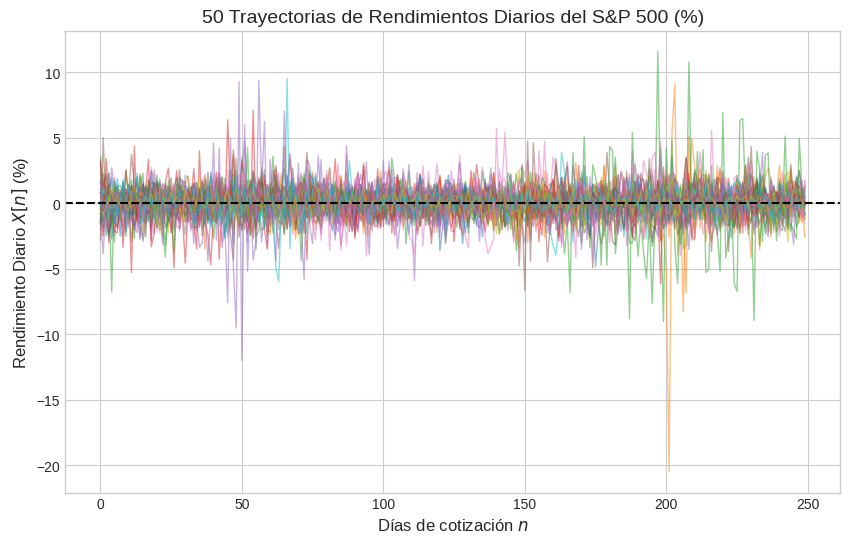

In [ ]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# Cálculo de los rendimientos diarios en porcentaje (se elimina el primer valor nulo)
rendimientos = precios.pct_change().dropna() * 100

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n (Rendimientos)
Y = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los rendimientos del año correspondiente
    datos = rendimientos[rendimientos.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recortan los datos a N_dias
        Y[i, :] = datos[:N_dias]

    elif len(datos) < N_dias:
        # Rellenamos con 0 (rendimiento nulo) los días faltantes
        # La opción 'constant' con constant_values=0 agrega ceros al final
        Y[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'constant', constant_values=0)

    else:
        Y[i, :] = datos

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), Y[i, :], alpha=0.5, lw=1)

plt.title('50 Trayectorias de Rendimientos Diarios del S&P 500 (%)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Rendimiento Diario $X[n]$ (%)', fontsize=12)
plt.axhline(0.0, color='black', linestyle='--')
plt.show()


#**Reto 5**
Repita los Retos 1, 2, 3 y 4 aplicando el código sobre la nueva matriz X (rendimientos) y analise los resultados. ¿Puede decir que este nuevo proceso es (aproximadamente) WSS?

RETO 1


In [ ]:
# MEDIA Y VARIANZA
mu_Y  = np.mean(Y, axis=0)
var_Y = np.var(Y, axis=0)
n_array_Y = np.arange(N_dias)


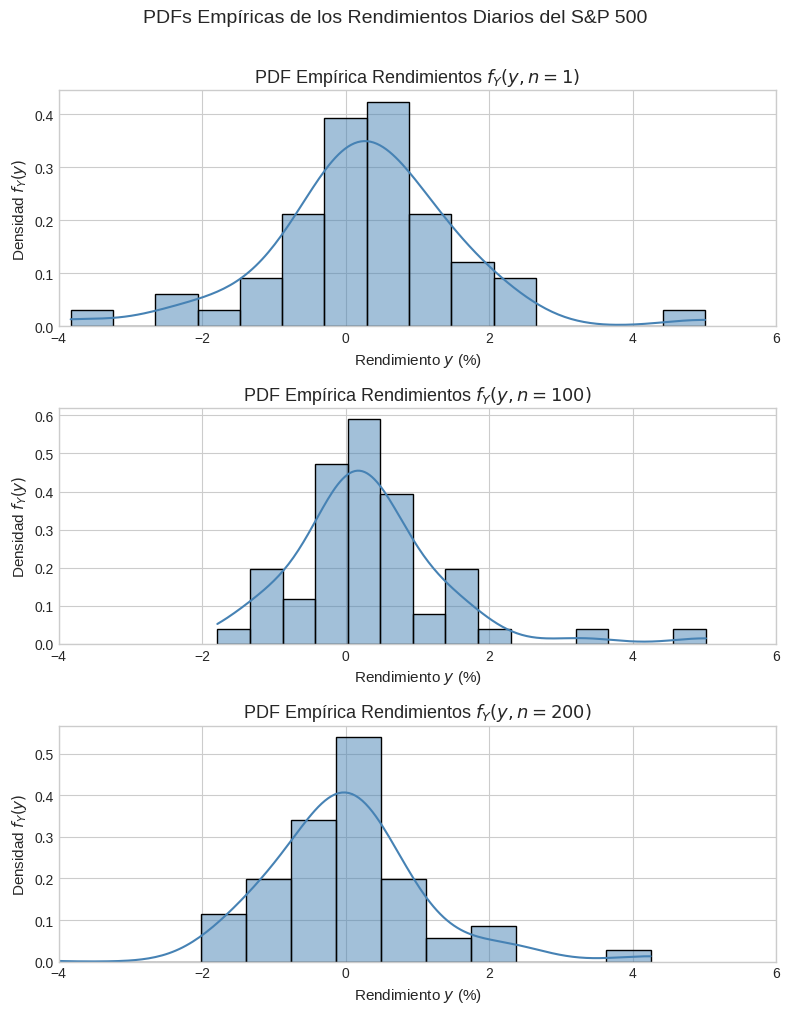

In [ ]:

# --- Reto 1 sobre Y: PDFs en n = 1, 100, 200 ---
pasos_Y = [1, 100, 200]
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i, n_step in enumerate(pasos_Y):
    Y_en_t = Y[:, n_step]
    sns.histplot(Y_en_t, kde=True, stat="density", ax=axes[i], color='steelblue', bins=15)
    axes[i].set_title(f'PDF Empírica Rendimientos $f_Y(y, n={n_step})$', fontsize=13)
    axes[i].set_xlabel('Rendimiento $y$ (%)', fontsize=11)
    axes[i].set_ylabel('Densidad $f_Y(y)$', fontsize=11)
    axes[i].set_xlim([-4, 6])

plt.suptitle('PDFs Empíricas de los Rendimientos Diarios del S&P 500', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

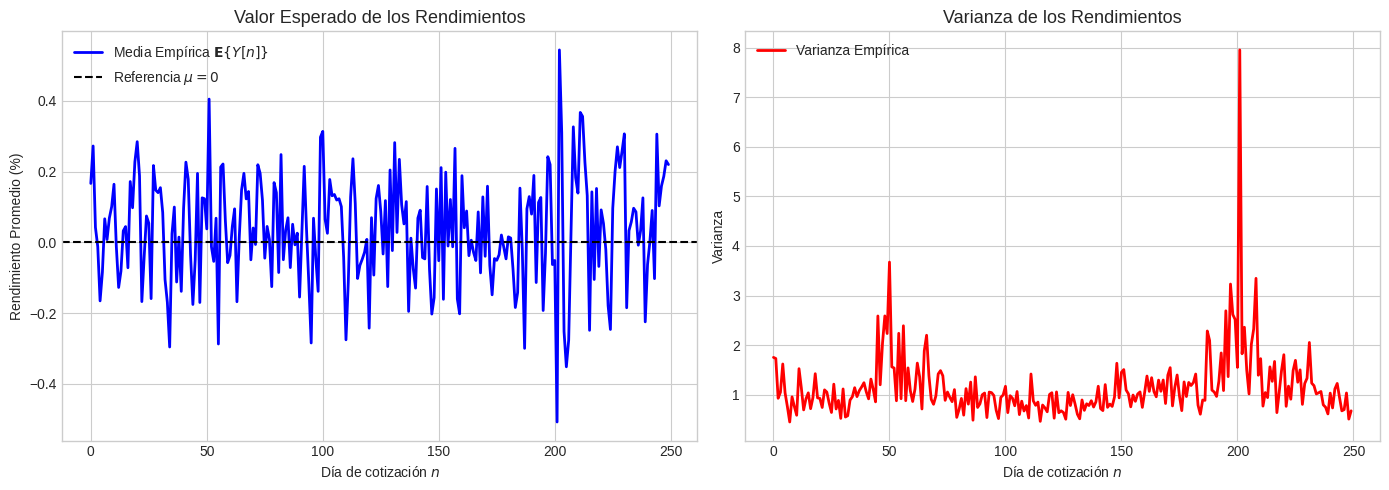

In [ ]:
# --- Reto 2 sobre Y: Valor Esperado y Varianza ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(n_array_Y, mu_Y, label=r'Media Empírica $\mathbf{E}\{Y[n]\}$', color='blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', label='Referencia $\mu = 0$')
ax1.set_title('Valor Esperado de los Rendimientos', fontsize=13)
ax1.set_xlabel('Día de cotización $n$')
ax1.set_ylabel('Rendimiento Promedio (%)')
ax1.legend()

ax2.plot(n_array_Y, var_Y, label='Varianza Empírica', color='red', lw=2)
ax2.set_title('Varianza de los Rendimientos', fontsize=13)
ax2.set_xlabel('Día de cotización $n$')
ax2.set_ylabel('Varianza')
ax2.legend()

plt.tight_layout()
plt.show()

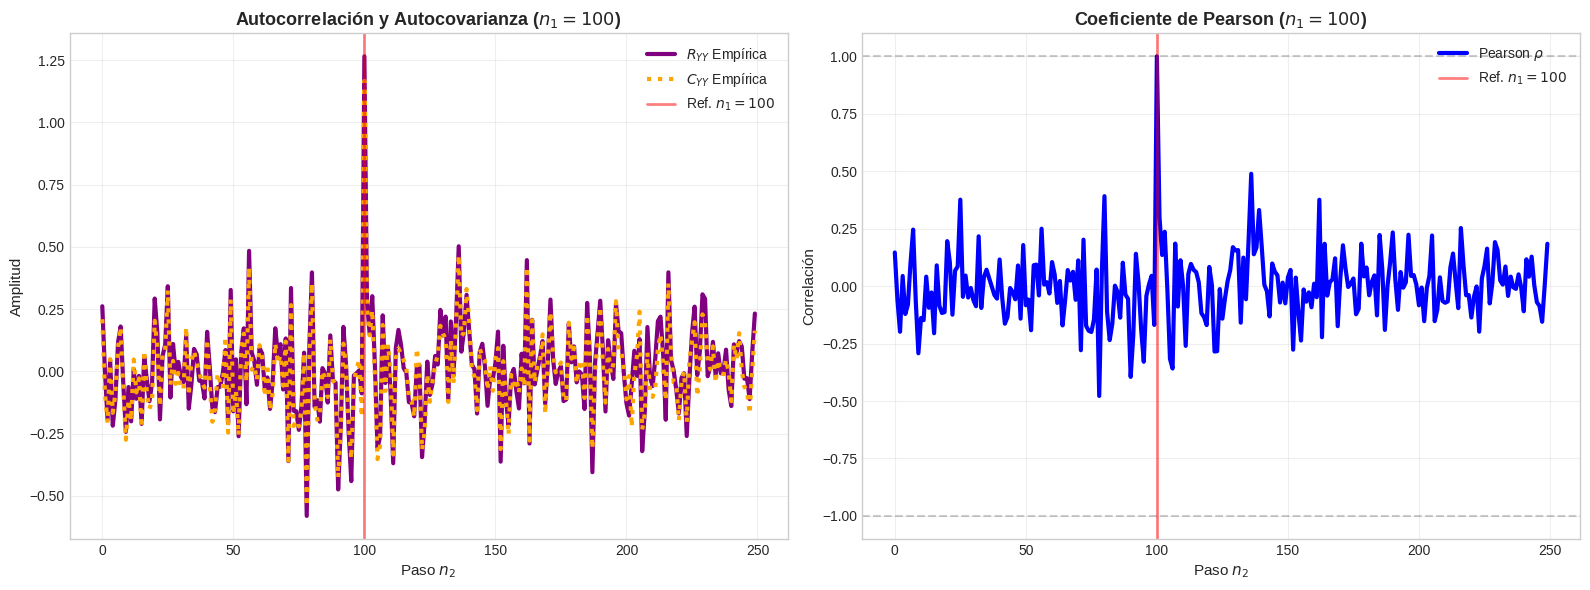

In [ ]:

# Incluya aquí el código del Reto 3
n1 = 100
N= 249
R_YY_empirica = np.zeros(N + 1)
C_YY_empirica = np.zeros(N + 1)
correlacion_pearson = np.zeros(N + 1)

# Cálculo a través del ensamble de las M realizaciones
for n2 in range(N + 1):
    # Autocorrelación: Esperanza del producto E[X(t1)*X(t2)]
    R_YY_empirica[n2] = np.mean(Y[:, n1] * Y[:, n2])

    # Autocovarianza: R_XX(t1,t2) - mu(t1)*mu(t2)
    C_YY_empirica[n2] = R_YY_empirica[n2] - (mu_Y[n1] * mu_Y[n2])

    # coeficiente de pearson para correlación
    correlacion_pearson[n2]= C_YY_empirica[n2]/ np.sqrt(var_Y[n1]*var_Y[n2])



# Autocorrelación / Autocovarianza Teórica para Caminata Aleatoria es min(t1, t2)
R_YY_teorica = [min(n1, n2) for n2 in range(N + 1)]

# Visualización
# Configuración de la figura: 1 fila, 2 columnas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Autocorrelación y Autocovarianza ---
ax1.plot(range(N + 1), R_YY_empirica, label=f'$R_{{YY}}$ Empírica', color='purple', lw=3)
ax1.plot(range(N + 1), C_YY_empirica, label=f'$C_{{YY}}$ Empírica', color='orange', linestyle=':', lw=3)
ax1.axvline(n1, linestyle='-', alpha=0.5, label=f'Ref. $n_1 = {n1}$', color='red', lw=2)

ax1.set_title(f'Autocorrelación y Autocovarianza ($n_1 = {n1}$)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Paso $n_2$', fontsize=11)
ax1.set_ylabel('Amplitud', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Correlación de Pearson ---
ax2.plot(range(N + 1), correlacion_pearson, label='Pearson $\\rho$', color='blue', lw=3)
ax2.axvline(n1, linestyle='-', alpha=0.5, label=f'Ref. $n_1 = {n1}$', color='red', lw=2)
# Añadimos líneas de referencia para Pearson (suelen ser entre -1 y 1)
ax2.axhline(1, color='black', linestyle='--', alpha=0.2)
ax2.axhline(-1, color='black', linestyle='--', alpha=0.2)

ax2.set_title(f'Coeficiente de Pearson ($n_1 = {n1}$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Paso $n_2$', fontsize=11)
ax2.set_ylabel('Correlación', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Ajuste final
plt.tight_layout()
plt.show()

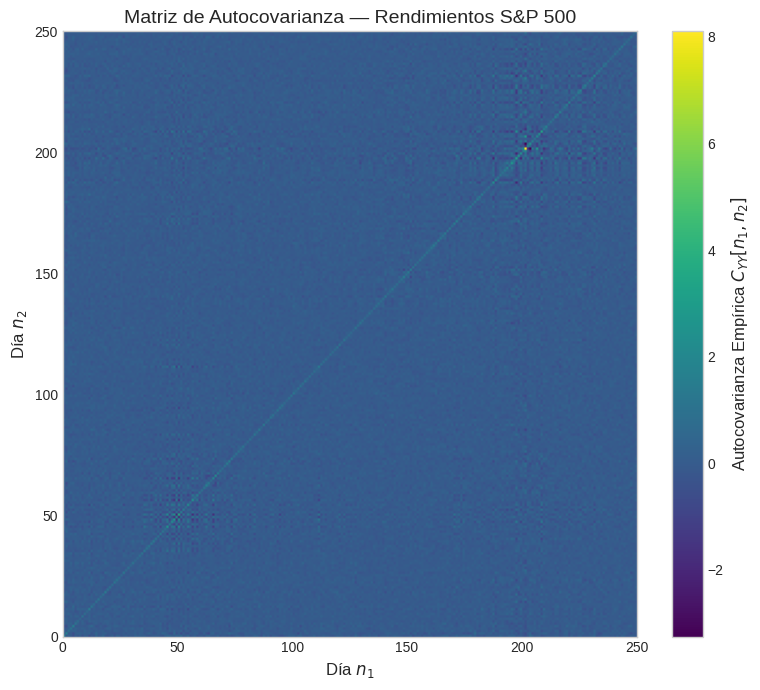

C_YY(100, 100)  = 1.188319
var_Y[100]      = 1.167099
Diferencia: 2.12e-02


In [ ]:


# --- Reto 4 sobre Y: Matriz de Autocovarianza ---
C_YY_matriz = np.cov(Y, rowvar=False)  # (250, 250)

fig, ax = plt.subplots(figsize=(8, 7))
img = ax.imshow(C_YY_matriz, origin='lower', cmap='viridis',
                extent=[0, N_dias, 0, N_dias], aspect='auto')
cbar = plt.colorbar(img, ax=ax)
cbar.set_label('Autocovarianza Empírica $C_{YY}[n_1, n_2]$', fontsize=12)
ax.set_title('Matriz de Autocovarianza — Rendimientos S&P 500', fontsize=14)
ax.set_xlabel('Día $n_1$', fontsize=12)
ax.set_ylabel('Día $n_2$', fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.show()

# Verificación numérica
C_Y_100_100 = C_YY_matriz[100, 100]
var_Y_100   = var_Y[100]
print(f"C_YY(100, 100)  = {C_Y_100_100:.6f}")
print(f"var_Y[100]      = {var_Y_100:.6f}")
print(f"Diferencia: {abs(C_Y_100_100 - var_Y_100):.2e}")


## Análisis — Reto 5: ¿Son los Rendimientos un proceso WSS?

### Reto 1 (PDFs de $Y[n]$)
Las tres distribuciones para $n = 1$, $n = 100$ y $n = 200$ lucen **visualmente similares**: campanas aproximadamente centradas en cero, con colas de amplitud comparable. A diferencia del precio normalizado, la dispersión no crece sistemáticamente con el tiempo.

### Reto 2 (Media y Varianza de $Y[n]$)
- **Media empírica**: oscila de forma ruidosa alrededor de cero en todos los días $n$, sin tendencia clara. Esto satisface la primera condición WSS: $\mu_Y[n] \approx \text{constante}$.
- **Varianza empírica**: fluctúa alrededor de un nivel aproximadamente estable (con algunos picos asociados a años de alta volatilidad, como la crisis de 2008 o el COVID-2020), pero sin la tendencia creciente observada en el precio.

### Reto 3 (Autocorrelación fijando $n_1 = 100$)
La autocovarianza $C_{YY}[100, n_2]$ cae rápidamente a cero para $n_2 \neq 100$, y el coeficiente de Pearson muestra un pico concentrado en $n_2 = 100$ con valores cercanos a cero en el resto. Esto indica que los rendimientos en días distintos son prácticamente **incorrelados**, comportamiento coherente con la hipótesis de mercados eficientes.

### Reto 4 (Matriz de Autocovarianza)
El mapa de calor muestra una **diagonal dominante** con valores cercanos a cero fuera de ella. A diferencia del precio (que presentaba gradientes de color pronunciados), aquí la diagonal es aproximadamente uniforme, sin variaciones sistemáticas. La ausencia de estructura fuera de la diagonal confirma la baja correlación temporal.

### Conclusión: ¿Es $Y[n]$ aproximadamente WSS?
**Sí**, los rendimientos diarios del S&P 500 pueden considerarse *aproximadamente* WSS:
1. Su media es aproximadamente constante en cero.
2. Su varianza no presenta tendencia creciente sostenida (aunque varía por regímenes de volatilidad).
3. Su función de autocovarianza depende casi exclusivamente de la diferencia $\tau = n_2 - n_1$ (es prácticamente nula para $\tau \neq 0$).

Esta propiedad es la base del modelo de **ruido blanco financiero** o **caminata aleatoria de rendimientos**.
